In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from hmm_utils import add_hmm_features, fit_best_hmm_from_results,  automatic_hmm_feature_selection, summarize_hmm_results, extract_best_hmm_feature_subset


In [59]:
df = pd.read_csv("deribit_enriched_data.csv")
df['timestamp']= pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)

df.head(3)

,open_spot,high_spot,low_spot,close_spot,volume_spot,cost_spot,open_perp,high_perp,low_perp,close_perp,...,std_72h_sq_return_close_perp,std_72h_sq_return_index_price,ATR_24h_spot,ATR_72h_spot,ATR_24h_spot_norm,ATR_72h_spot_norm,ATR_24h_perp,ATR_72h_perp,ATR_24h_perp_norm,ATR_72h_perp_norm
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-12-12 12:00:00+00:00,41819.99,41819.99,41819.99,41819.99,0.0112,468.383888,41590.5,41903.0,41590.5,41845.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-12 13:00:00+00:00,41900.00,41900.00,41791.98,41870.00,3.1823,133157.488249,41855.0,42059.5,41752.0,41815.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-12 14:00:00+00:00,41729.96,41730.00,41729.96,41730.00,0.0567,2366.090988,41815.0,41875.5,41301.0,41472.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
# =========================================================
# FINAL optimized HMM feature set (non-redundant + stable)
# =========================================================

# --- Activity (level + shock) ---
basic_feature = [
    "volume_perp",
    "volume_spot",
    "price_prep"
]

activity_features = [
    "log_volume_perp",         # core activity level
    "ma_24h_volume_perp",       # activity shock
]

# --- Market structure ---
structure_features = [
    "volume_perp_to_spot",     # derivatives dominance
]

# --- Volatility (ONE robust proxy) ---
volatility_features = [
    "std_72h_sq_return_close_perp",  # smoother regime signal
]

# --- Price dynamics (minimal) ---
price_features = [
    "return_24h_close_perp",   # trend
    "z_24h_close_perp",        # deviation
]

# --- Leverage / stress (MOST IMPORTANT BLOCK) ---
leverage_features = [
    "cost_x_volume_perp",      # core stress feature (MUST HAVE)
    "z_24h_cost_perp",         # abnormal funding / cost
]

# --- Funding (optional but useful) ---
funding_features = [
    "interest_8h",
    "interest_1h",
]

# --- Combine ---
all_candidates = (
    basic_feature +
    activity_features +
    structure_features +
    volatility_features +
    price_features +
    leverage_features +
    funding_features
)

# --- Keep only existing ---
hmm_candidate_features = [f for f in all_candidates if f in df.columns]

print(f"Using {len(hmm_candidate_features)} candidate features")
print(hmm_candidate_features)

Using 10 candidate features
['volume_perp', 'volume_spot', 'log_volume_perp', 'ma_24h_volume_perp', 'volume_perp_to_spot', 'std_72h_sq_return_close_perp', 'cost_x_volume_perp', 'z_24h_cost_perp', 'interest_8h', 'interest_1h']


In [ ]:
results = automatic_hmm_feature_selection(
    df=df,
    candidate_features=hmm_candidate_features,
    subset_min_size=2,
    subset_max_size=4,
    n_states_list=[3],
    min_state_fraction_threshold=0.05,
    top_k=20
)


HMM feature search:   0%|          | 0/375 [00:00<?, ?fit/s]

HMM feature search:   7%|▋         | 28/375 [01:03<11:06,  1.92s/fit]

In [ ]:
summary = summarize_hmm_results(results, top_n=10, stringify_features=True)
best = extract_best_hmm_feature_subset(results)

hmm, scaler, best_features, best_n_states = fit_best_hmm_from_results(
    df=df,
    results_df=results
)
df_hmm = add_hmm_features(df, hmm, scaler, best_features)
df_full = pd.concat([df, df_hmm], axis=1)

price_col = "close_perp"   # change if needed

# auto-detect HMM columns
state_col = [c for c in df_full.columns if "state" in c.lower()][0]
prob_cols = [c for c in df_full.columns if "prob" in c.lower()]


In [ ]:
summary.to_csv("hmm_feature_selection_summary.csv", index=False)
summary

,feature_cols,n_states,n_features,n_obs_used,eligible,selection_score,train_loglik,min_state_fraction,avg_self_transition,median_run_length,avg_entropy
0,"volume_perp, log_volume_perp, cost_x_volume_perp",3,3,12303,True,39624.828691,39624.828691,0.141429,0.627724,2.0,0.037424
1,"volume_perp, cost_x_volume_perp",3,2,12303,True,30354.083184,30354.083184,0.091441,0.649675,2.0,0.080060
2,"volume_perp, volume_spot, cost_x_volume_perp",3,3,12303,True,20926.542292,20926.542292,0.104040,0.640447,2.0,0.074112
3,"volume_perp, cost_x_volume_perp, z_24h_cost_perp",3,3,12280,True,19096.497220,19096.497220,0.092752,0.628318,2.0,0.078739
4,"log_volume_perp, cost_x_volume_perp",3,2,12303,True,17563.189912,17563.189912,0.123954,0.645961,2.0,0.064886
5,"volume_perp, ma_24h_volume_perp, cost_x_volume...",3,3,12280,True,16621.705587,16621.705587,0.096987,0.686814,2.0,0.078090
6,"volume_perp, std_72h_sq_return_close_perp, cos...",3,3,12231,True,15162.661704,15162.661704,0.123048,0.731287,2.0,0.072620
7,"volume_perp, cost_x_volume_perp, interest_8h",3,3,12303,True,14658.902280,14658.902280,0.102170,0.695949,2.0,0.077047
8,"volume_spot, cost_x_volume_perp",3,2,12303,True,10348.160166,10348.160166,0.107779,0.655753,2.0,0.113042
9,"cost_x_volume_perp, z_24h_cost_perp",3,2,12280,True,7831.995650,7831.995650,0.093648,0.630691,2.0,0.126761


In [ ]:
state_counts = df_full["hmm_state"].value_counts(normalize=True).sort_index()
print(state_counts)

hmm_state
0.0    0.393056
1.0    0.130596
2.0    0.476348
Name: proportion, dtype: float64


In [ ]:
df_full.groupby(state_col).agg({
    "close_perp": ["mean"],
    "abs_return_close_perp": ["mean"],
    "volume_perp": ["mean"]
})

,close_perp,abs_return_close_perp,volume_perp
,mean,mean,mean
hmm_state,,,
0.0,82225.882630,0.003720,384.462500
1.0,81071.451456,0.008322,1250.598234
2.0,81755.389998,0.001838,116.968202


In [ ]:
# manually define interpretation (adjust after inspection)
regime_labels = {
    0: "Low Activity",
    1: "Stress",
    2: "Active"
}

regime_colors = {
    0: "lightgrey",
    1: "lightcoral",
    2: "lightgreen"
}

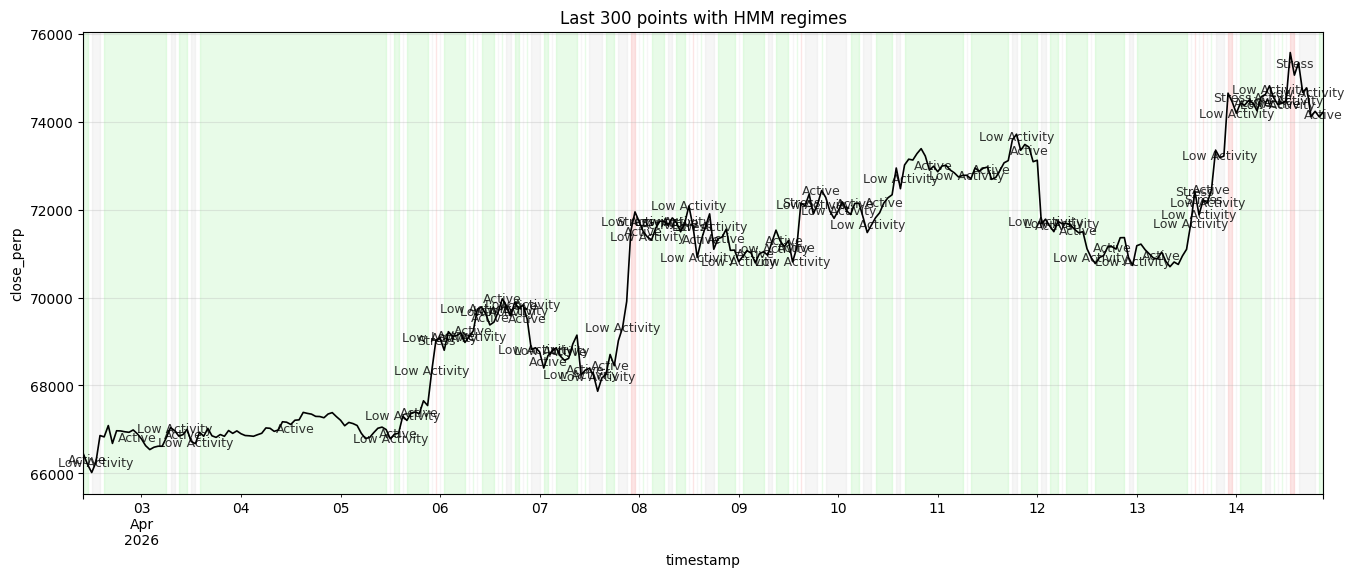

In [ ]:
# =========================
# CONFIG
# =========================
N = 100

# =========================
# DATA
# =========================
plot_df = df_full[[price_col, state_col]].dropna().tail(N)

ax = plot_df[price_col].plot(
    figsize=(16, 6),
    lw=1.2,
    color="black",
    title=f"Last {N} points with HMM regimes"
)

state_series = plot_df[state_col]
change_points = state_series.ne(state_series.shift()).cumsum()

# =========================
# PLOT REGIMES + LABELS
# =========================
for _, block in plot_df.groupby(change_points):
    state = int(block[state_col].iloc[0])
    
    x0 = block.index[0]
    x1 = block.index[-1]

    label = regime_labels.get(state, f"State {state}")
    color = regime_colors.get(state, "grey")

    # background
    ax.axvspan(x0, x1, alpha=0.2, color=color)

    # position label in the middle of segment
    x_mid = block.index[len(block) // 2]
    y_mid = block[price_col].median()

    ax.text(
        x_mid,
        y_mid,
        label,
        fontsize=9,
        ha="center",
        va="center",
        alpha=0.8
    )

ax.set_ylabel(price_col)
ax.grid(True, alpha=0.3)

plt.show()

In [ ]:
states = df_full["hmm_state"].dropna().values

runs = []
current = 1

for i in range(1, len(states)):
    if states[i] == states[i-1]:
        current += 1
    else:
        runs.append(current)
        current = 1
runs.append(current)

print("Mean run length:", np.mean(runs))
print("Median run length:", np.median(runs))

Mean run length: 2.9348790611134965
Median run length: 2.0


In [ ]:
trans_mat = pd.DataFrame(
    hmm.transmat_,
    index=[f"from_{i}" for i in range(best_n_states)],
    columns=[f"to_{i}" for i in range(best_n_states)]
)

print(trans_mat)

            to_0      to_1      to_2
from_0  0.584530  0.141035  0.274435
from_1  0.448548  0.530562  0.020890
from_2  0.206667  0.025252  0.768081


In [ ]:
print("Avg max prob:", df_full["hmm_max_prob"].mean())
print("Avg entropy:", df_full["hmm_entropy"].mean())

Avg max prob: 0.9848834428548977
Avg entropy: 0.035718367652762435


In [ ]:
state_summary = df_full.groupby("hmm_state")[best_features].mean()
print(state_summary)

           volume_perp  log_volume_perp  cost_x_volume_perp
hmm_state                                                  
0.0         384.462500         5.900645        1.307498e+10
1.0        1250.598234         7.010669        1.762671e+11
2.0         116.968202         4.629298        1.327168e+09


<Axes: title={'center': 'State Distribution'}, xlabel='hmm_state'>

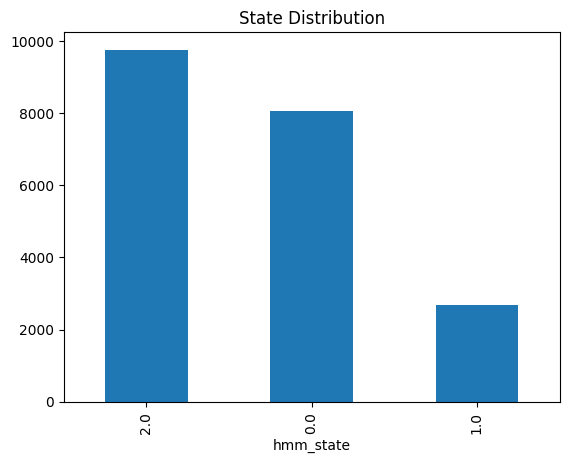

In [ ]:
df_full["hmm_state"].value_counts().plot(kind="bar", title="State Distribution")

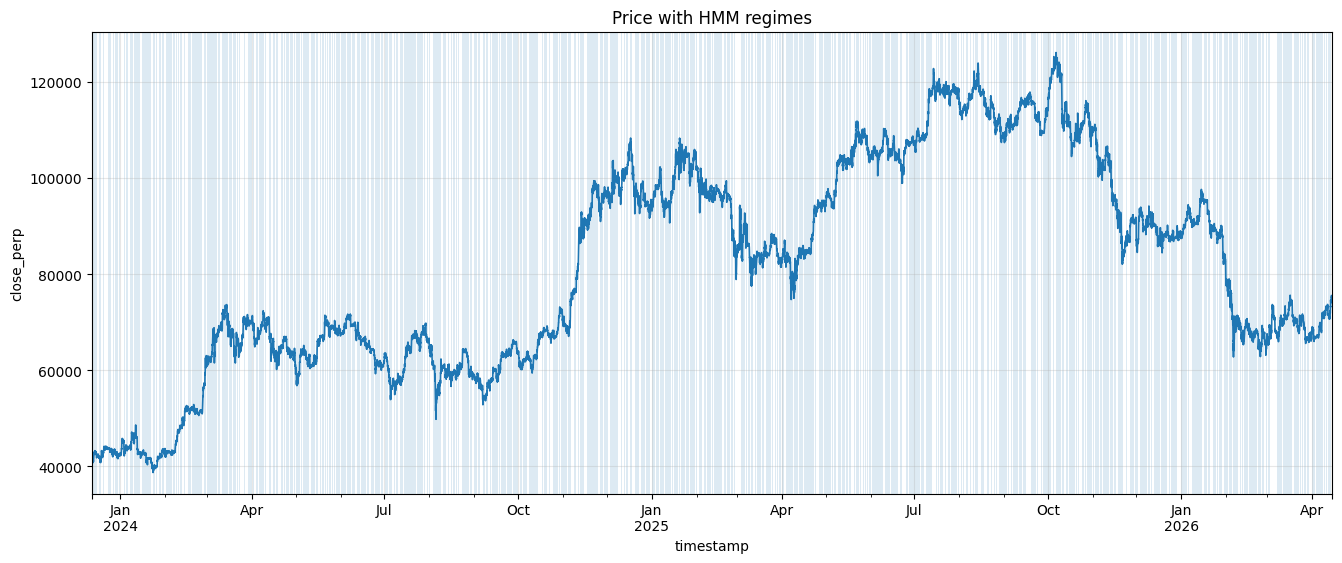

In [ ]:
plot_df = df_full[[price_col, state_col]].dropna().copy()

ax = plot_df[price_col].plot(figsize=(16, 6), lw=1.2, title="Price with HMM regimes")

state_series = plot_df[state_col]
change_points = state_series.ne(state_series.shift()).cumsum()

for _, block in plot_df.groupby(change_points):
    x0 = block.index[0]
    x1 = block.index[-1]
    ax.axvspan(x0, x1, alpha=0.15)

ax.set_ylabel(price_col)
ax.grid(True, alpha=0.3)

plt.show()

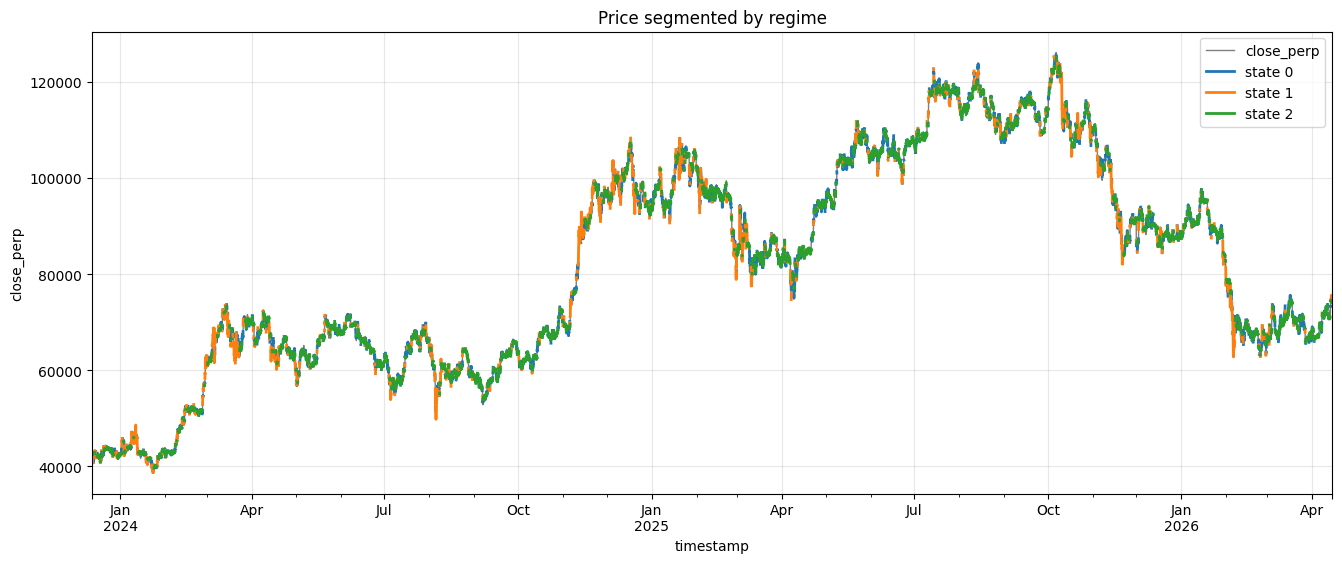

In [ ]:
plot_df = df_full[[price_col, state_col]].dropna().copy()

ax = plot_df[price_col].plot(figsize=(16, 6), lw=1.0, color="black", alpha=0.5, title="Price segmented by regime")

states = sorted(plot_df[state_col].unique())

for s in states:
    plot_df[price_col].where(plot_df[state_col] == s).plot(
        ax=ax, lw=2, label=f"state {int(s)}"
    )

ax.set_ylabel(price_col)
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

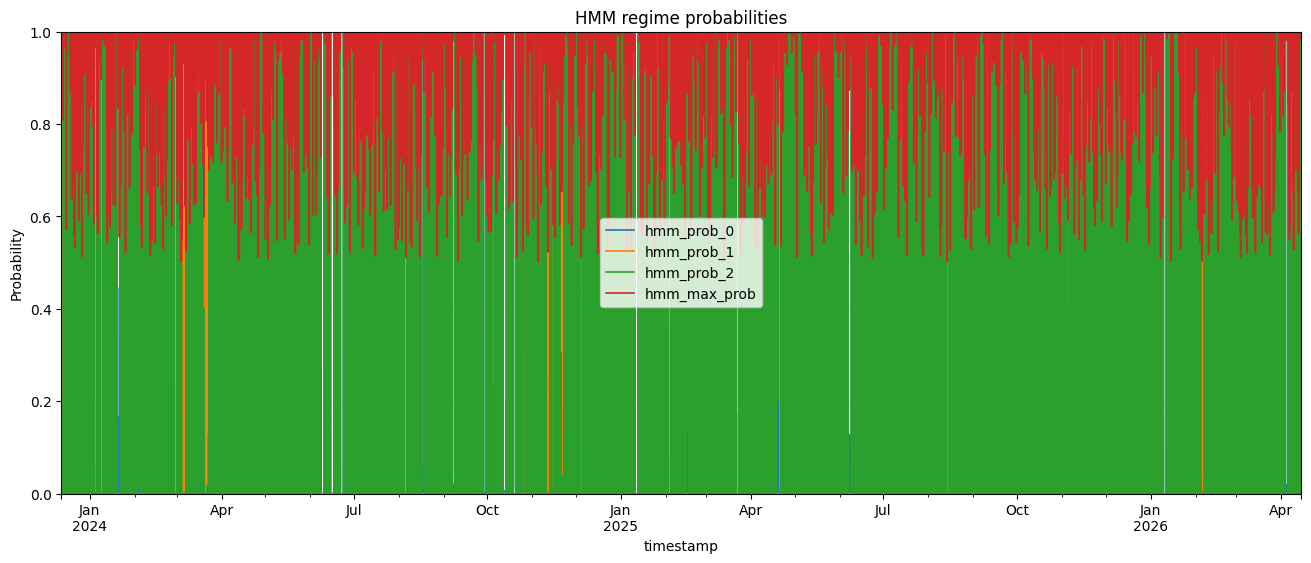

In [ ]:
plot_df = df_full[prob_cols].dropna().copy()

ax = plot_df.plot(figsize=(16, 6), lw=1.2, title="HMM regime probabilities")

ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.show()